# Data cleaning and feature selection

In [2]:
#import libraries
import pandas as pd
import numpy as np

In [3]:
#reading parquet file
parquet_file = 'la_crime_data_raw.parquet'
df = pd.read_parquet(parquet_file)

In [4]:
#sanity check the data
df.head()

,dr_no,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,part_1_2,crm_cd,crm_cd_desc,...,crm_cd_1,location,lat,lon,weapon_used_cd,weapon_desc,cross_street,crm_cd_2,crm_cd_3,crm_cd_4
0,211507896,2021-04-11,2020-11-07,0845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,354,7800 BEEMAN AV,34.2124,-118.4092,NaN,NaN,NaN,NaN,NaN,NaN
1,201516622,2020-10-21,2020-10-18,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,230,ATOLL AV,34.1993,-118.4203,200,KNIFE WITH BLADE 6INCHES OR LESS,N GAULT,NaN,NaN,NaN
2,240913563,2024-12-10,2020-10-30,1240,09,Van Nuys,0933,2,354,THEFT OF IDENTITY,...,354,14600 SYLVAN ST,34.1847,-118.4509,NaN,NaN,NaN,NaN,NaN,NaN
3,210704711,2020-12-24,2020-12-24,1310,07,Wilshire,0782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,331,6000 COMEY AV,34.0339,-118.3747,NaN,NaN,NaN,NaN,NaN,NaN
4,201418201,2020-10-03,2020-09-29,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,420,4700 LA VILLA MARINA,33.9813,-118.4350,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
#checking the shape of the data
df.shape

(1004894, 28)

In [6]:
#checking the data types
df.dtypes

dr_no                        str
date_rptd         datetime64[us]
date_occ          datetime64[us]
time_occ                     str
area                         str
area_name                    str
rpt_dist_no                  str
part_1_2                     str
crm_cd                       str
crm_cd_desc                  str
mocodes                      str
vict_age                     str
vict_sex                     str
vict_descent                 str
premis_cd                    str
premis_desc                  str
status                       str
status_desc                  str
crm_cd_1                     str
location                     str
lat                      float64
lon                      float64
weapon_used_cd               str
weapon_desc                  str
cross_street                 str
crm_cd_2                     str
crm_cd_3                     str
crm_cd_4                     str
dtype: object

In [7]:
#checking for missing values
df.isnull().sum()

dr_no                   0
date_rptd               0
date_occ                0
time_occ                0
area                    0
area_name               0
rpt_dist_no             0
part_1_2                0
crm_cd                  0
crm_cd_desc             0
mocodes            151598
vict_age                0
vict_sex           144631
vict_descent       144643
premis_cd              16
premis_desc           588
status                  1
status_desc             0
crm_cd_1               11
location                0
lat                     0
lon                     0
weapon_used_cd     677678
weapon_desc        677678
cross_street       850666
crm_cd_2           935740
crm_cd_3          1002580
crm_cd_4          1004830
dtype: int64

In [8]:
#checking for duplicates
print(df.duplicated().sum())

0


- Crm_cd_2, Crm_cd_3 and Crm_cd_4 columns can be dropped since there are more than 90% of data is missing.
Besides they are not adding any value!
- Other columns to drop and the reason for dropping are
    - area (this is just area code which can be covered by area_name)
    - rpt_dist_no (this is just district code and adds no value for current analysis)
    - part_1_2
    - crm_cd
    - mocodes
    - premis_cd
    - status
    - location
    - weapon_used_cd
    - cross_street

In [9]:
#drop certain columns
columns_to_drop = ['area', 'rpt_dist_no', 'part_1_2', 'crm_cd', 'mocodes', 'premis_cd', 'status',
                   'weapon_used_cd', 'crm_cd_1', 'crm_cd_2', 'crm_cd_3', 'crm_cd_4', 'location', 'cross_street']
df.drop(columns=columns_to_drop, inplace=True)

In [10]:
#checking the shape of the data after dropping columns
df.shape

(1004894, 14)

In [11]:
df.columns

Index(['dr_no', 'date_rptd', 'date_occ', 'time_occ', 'area_name',
       'crm_cd_desc', 'vict_age', 'vict_sex', 'vict_descent', 'premis_desc',
       'status_desc', 'lat', 'lon', 'weapon_desc'],
      dtype='str')

In [12]:
# convert column types
df['dr_no'] = df['dr_no'].astype('int64')
#Change time_occ to datetime
df['time_occ'] = pd.to_datetime(df['time_occ'], format='%H%M', errors='coerce').dt.time

In [13]:
#extracting hour and minute from time_occ
df['hour'] = df['time_occ'].apply(lambda x: x.hour if pd.notnull(x) else np.nan)
df['minute'] = df['time_occ'].apply(lambda x: x.minute if pd.notnull(x) else np.nan)

In [14]:
#checking hour and minute columns
df[['time_occ','hour', 'minute']].head()

,time_occ,hour,minute
0,08:45:00,8,45
1,18:45:00,18,45
2,12:40:00,12,40
3,13:10:00,13,10
4,18:30:00,18,30


In [15]:
#checking the data types after conversion
df.dtypes

dr_no                    int64
date_rptd       datetime64[us]
date_occ        datetime64[us]
time_occ                object
area_name                  str
crm_cd_desc                str
vict_age                   str
vict_sex                   str
vict_descent               str
premis_desc                str
status_desc                str
lat                    float64
lon                    float64
weapon_desc                str
hour                     int64
minute                   int64
dtype: object

In [18]:
#changing vict_age to integer
df['vict_age'] = pd.to_numeric(df['vict_age'], errors='coerce').astype('int64')


In [19]:
#checking the data types after conversion
df.dtypes

dr_no                    int64
date_rptd       datetime64[us]
date_occ        datetime64[us]
time_occ                object
area_name                  str
crm_cd_desc                str
vict_age                 int64
vict_sex                   str
vict_descent               str
premis_desc                str
status_desc                str
lat                    float64
lon                    float64
weapon_desc                str
hour                     int64
minute                   int64
dtype: object

In [20]:
# Create a new column 'vict_descent_group' based on the values in 'vict_descent' A for Asian, B for Black, H for Hispanic, W for White, O for Other, U for Unknown
df['vict_descent_group'] = df['vict_descent'].apply(lambda x: 'Asian' if x in ['C', 'D', 'F', 'J', 'K', 'V', 'Z'] else x)
df['vict_descent_group'] = df['vict_descent_group'].replace({'A':'Other Asian', 'B': 'Black', 'G':'Guamanian', 'H': 'Hispanic', 'I':'American Indian/Alaskan Native', 'L':'Laotian', 'W': 'White', 'O': 'Other', 'P':'Pacific Islander', 'S':'Samoan', 'U':'Hawaiian', 'X':'Unknown'})

In [21]:
df['vict_descent_group'].value_counts()

vict_descent_group
Hispanic                          296370
White                             201429
Black                             135809
Unknown                           106661
Other                              78001
Other Asian                        21338
Asian                              18908
American Indian/Alaskan Native      1015
Pacific Islander                     288
Hawaiian                             221
Laotian                               77
Guamanian                             74
Samoan                                58
-                                      2
Name: count, dtype: int64

In [22]:
#checking the data types after conversion
df.dtypes

dr_no                          int64
date_rptd             datetime64[us]
date_occ              datetime64[us]
time_occ                      object
area_name                        str
crm_cd_desc                      str
vict_age                       int64
vict_sex                         str
vict_descent                     str
premis_desc                      str
status_desc                      str
lat                          float64
lon                          float64
weapon_desc                      str
hour                           int64
minute                         int64
vict_descent_group               str
dtype: object

In [24]:
#checking the data itself
df.head(3)

,dr_no,date_rptd,date_occ,time_occ,area_name,crm_cd_desc,vict_age,vict_sex,vict_descent,premis_desc,status_desc,lat,lon,weapon_desc,hour,minute,vict_descent_group
0,211507896,2021-04-11,2020-11-07,08:45:00,N Hollywood,THEFT OF IDENTITY,31,M,H,SINGLE FAMILY DWELLING,Invest Cont,34.2124,-118.4092,NaN,8,45,Hispanic
1,201516622,2020-10-21,2020-10-18,18:45:00,N Hollywood,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",32,M,H,SIDEWALK,Invest Cont,34.1993,-118.4203,KNIFE WITH BLADE 6INCHES OR LESS,18,45,Hispanic
2,240913563,2024-12-10,2020-10-30,12:40:00,Van Nuys,THEFT OF IDENTITY,30,M,W,SINGLE FAMILY DWELLING,Invest Cont,34.1847,-118.4509,NaN,12,40,White


In [25]:
df['vict_age'].describe()

count    1.004894e+06
mean     2.891862e+01
std      2.199267e+01
min     -4.000000e+00
25%      0.000000e+00
50%      3.000000e+01
75%      4.400000e+01
max      1.200000e+02
Name: vict_age, dtype: float64

In [26]:
#removing outliers in vict_age column, removing values less than 0 and greater than 100
df = df[(df['vict_age'] >= 0) & (df['vict_age'] <= 100)]


In [ ]:
#rows before was 1004894 so checking the shape of the data after removing outliers
df.shape 

(1004756, 17)

(array([270627.,   3039.,   9281.,  27788.,  78958., 100888., 104330.,
         90625.,  71516.,  58467.,  54269.,  44087.,  35371.,  23923.,
         14903.,   8417.,   4512.,   2149.,    915.,    691.]),
 array([ 0.  ,  4.95,  9.9 , 14.85, 19.8 , 24.75, 29.7 , 34.65, 39.6 ,
        44.55, 49.5 , 54.45, 59.4 , 64.35, 69.3 , 74.25, 79.2 , 84.15,
        89.1 , 94.05, 99.  ]),
 <BarContainer object of 20 artists>)

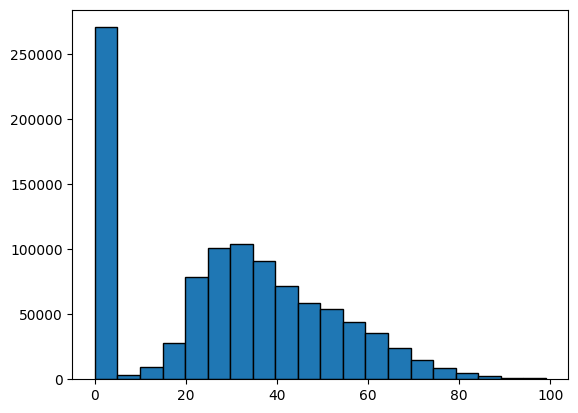

In [28]:
#checking the distribution of vict_age column after removing outliers
import matplotlib.pyplot as plt
plt.hist(df['vict_age'], bins=20, edgecolor='black')

([<matplotlib.axis.XTick at 0x2d65b967390>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25'),
  Text(30, 0, '30'),
  Text(35, 0, '35'),
  Text(40, 0, '40'),
  Text(45, 0, '45'),
  Text(50, 0, '50'),
  Text(55, 0, '55'),
  Text(60, 0, '60'),
  Text(65, 0, '65'),
  Text(70, 0, '70'),
  Text(75, 0, '75'),
  Text(80, 0, '80'),
  Text(85, 0, '85'),
  Text(90, 0, '90'),
  Text(95, 0, '95'),
  Text(100, 0, '100')])

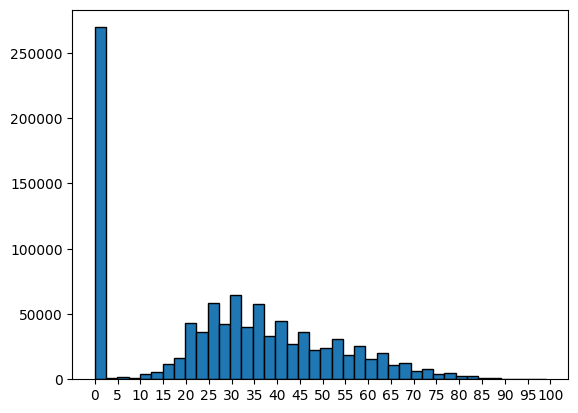

In [31]:
#histogram of vict_age using different bin sizes
plt.hist(df['vict_age'], bins=40, edgecolor='black')
#show x-axis labels
plt.xticks(range(0, 101, 5))

### Data is incorrect as there are significantly more victims in the age 0
- Further investigation is needed to understand why there are so many victims in the age 0, 
- It could be a data entry error or it could be that the age of the victim was not recorded and was defaulted to 0. 
- It is important to investigate this further before making any conclusions about the data.
- For now, converting 0 into NaN or NULL

In [32]:
#converting 0 in vict_age to NaN
df['vict_age'] = df['vict_age'].replace(0, np.nan)

(array([  2584.,   3931.,  14772.,  46721.,  90954., 106148.,  82455.,
         84697.,  68177.,  58689.,  51064.,  42588.,  33079.,  18132.,
         14903.,   8417.,   4512.,   2149.,    915.,    691.]),
 array([ 2.  ,  6.85, 11.7 , 16.55, 21.4 , 26.25, 31.1 , 35.95, 40.8 ,
        45.65, 50.5 , 55.35, 60.2 , 65.05, 69.9 , 74.75, 79.6 , 84.45,
        89.3 , 94.15, 99.  ]),
 <BarContainer object of 20 artists>)

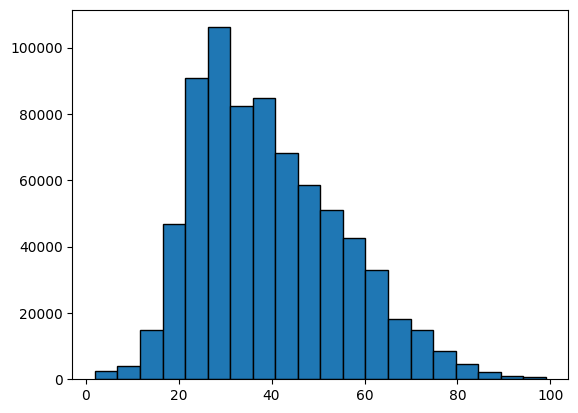

In [34]:
#histogram of vict_age column after removing outliers
plt.hist(df['vict_age'], bins=20, edgecolor='black')

In [35]:
df.shape

(1004756, 17)

In [36]:
df.info()

<class 'pandas.DataFrame'>
Index: 1004756 entries, 0 to 1004893
Data columns (total 17 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   dr_no               1004756 non-null  int64         
 1   date_rptd           1004756 non-null  datetime64[us]
 2   date_occ            1004756 non-null  datetime64[us]
 3   time_occ            1004756 non-null  object        
 4   area_name           1004756 non-null  str           
 5   crm_cd_desc         1004756 non-null  str           
 6   vict_age            735578 non-null   float64       
 7   vict_sex            860126 non-null   str           
 8   vict_descent        860114 non-null   str           
 9   premis_desc         1004168 non-null  str           
 10  status_desc         1004756 non-null  str           
 11  lat                 1004756 non-null  float64       
 12  lon                 1004756 non-null  float64       
 13  weapon_desc         327204 n

In [37]:
#make a copy of the dataframe
cleaned_df = df.copy()

In [38]:
#export filtered dataframe to parquet file
cleaned_df.to_parquet('la_crime_data_CLEANED.parquet', index=False)

As the dataset is over 1 million rows, duckdb should be used to query

In [39]:
#import duckdb library
import duckdb

In [40]:
#create a database connection
conn = duckdb.connect('CLEANED_database_1.db')

In [41]:
#connect la_crime_data_CLEANED.parquet file to the database
conn.execute(''' CREATE TABLE crimes AS SELECT * FROM 'la_crime_data_CLEANED.parquet' ''')

### See further analysis on SQL queries on duckdb